# 05 — ML Model Development: Part 2 (Sale Effectiveness Analysis)

Predicts **how effective a Steam sale event is** at driving player engagement — measured as `uplift_percent` (regression) and `uplift_tier` (classification).

**Data source:** `cleaned_sale_events` table from `steam.db` — one row per `(game, sale_event)` pair. Built by `02_data_cleaning` from raw price-history and SteamCharts CCU records, with game features merged in.

**ML problems:**
- **[Regression]** Predict `uplift_percent` — the % increase in concurrent players during a sale window vs. a pre-sale baseline.
- **[Classification]** Predict `uplift_tier` — High Impact / Moderate / Low / None — so developers can anticipate whether joining a sale will move the needle.

**Steps:**
1. Load & inspect the data
2. Define targets (Step 5.1)
3. Feature engineering (Step 5.2)
4. Train/test split (Step 5.3)
5. Regression models (Step 5.4)
6. Classification models (Step 5.5)
7. Combined insights & decision tree strategy visualization (Step 5.6)

## Setup

In [1]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    GroupShuffleSplit,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.utils.class_weight import compute_class_weight

# Bootstrap: make `src` importable
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebook_setup import setup_notebook
from src.plot_style import PALETTE, TIER_COLORS

conn, paths = setup_notebook()

Connected to: c:\Users\Sam\Documents\College\2026 Spring Term\DMW\Y2T2-Final-Project\data\steam.db
Tables (14): ['app_list', 'cleaned_discount_panel', 'cleaned_games', 'cleaned_sale_events', 'game_categories', 'game_genres', 'games', 'itad_mapping', 'price_history', 'review_timestamps', 'reviews_summary', 'steamcharts_history', 'steamspy', 'steamspy_tags']


## Step 5.1 — Define Part 2 Targets

Both target columns were constructed during data cleaning at the **sale-event level** — each row is one (appid, sale_event) pair:

| Column | Type | Description |
|--------|------|-------------|
| `uplift_percent` | float | % change in concurrent players during this sale vs. a pre-sale baseline |
| `uplift_tier` | string | Ordinal bucket: **High Impact** (>50%) / **Moderate** (20–50%) / **Low** (5–20%) / **None** (<5% or negative) |

We model every sale event with measurable uplift — i.e. drop only rows where `uplift_percent` is null because SteamCharts CCU coverage was missing around the sale window.

In [2]:
# Read from the sale-event-level table built by 02_data_cleaning.
# Each row = one (game, sale_event) pair. Joining the raw `games` table for
# the few game-level columns that aren't merged into cleaned_sale_events.
# (achievements_total is computed during cleaning but not saved into cleaned_games,
#  so we pull it from the raw collection table.)
raw = pd.read_sql('''
    SELECT
        e.*,
        COALESCE(g.achievements_total, 0) AS achievements_total
    FROM cleaned_sale_events e
    LEFT JOIN games g ON g.appid = e.appid
''', conn)
print(f'Total sale events:  {len(raw):,}')
print(f'Unique games:       {raw["appid"].nunique():,}')
print(f'Columns:            {len(raw.columns)}')

raw[['title', 'sale_type', 'discount_percent',
     'uplift_percent', 'uplift_tier',
     'baseline_players', 'during_players']].head(8)

Total sale events:  213,959
Unique games:       4,153
Columns:            34


,title,sale_type,discount_percent,uplift_percent,uplift_tier,baseline_players,during_players
0,Counter-Strike,Winter Sale,75,7.430167,Low,56957.0,61189.0
1,Counter-Strike,Winter Sale,75,6.535488,Low,61189.0,65188.0
2,Counter-Strike,Weekend Deal,75,NaN,Unknown,NaN,NaN
3,Counter-Strike,Weekend Deal,75,NaN,Unknown,NaN,NaN
4,Counter-Strike,Summer Sale,75,NaN,Unknown,NaN,NaN
5,Counter-Strike,Winter Sale,75,2.302516,None,39826.0,40743.0
6,Counter-Strike,Winter Sale,75,NaN,Unknown,NaN,NaN
7,Counter-Strike,Weekend Deal,75,NaN,Unknown,NaN,NaN


In [3]:
# Filter funnel — keep events with measurable uplift
print('--- filter funnel ---')
print(f'  cleaned_sale_events total           : {len(raw):>6,}')
print(f'  + uplift_percent not null           : {raw["uplift_percent"].notna().sum():>6,}')
print(f'  + baseline_players not null         : {(raw["uplift_percent"].notna() & raw["baseline_players"].notna()).sum():>6,}')

df = raw[raw['uplift_percent'].notna() & raw['baseline_players'].notna()].copy()
print(f'\nModeling dataset: {len(df):,} sale events  ({df["appid"].nunique():,} unique games)')

print(f'\nuplift_tier distribution:')
print(df['uplift_tier'].value_counts())

print(f'\nuplift_percent stats:')
print(df['uplift_percent'].describe().round(2))

--- filter funnel ---
  cleaned_sale_events total           : 213,959
  + uplift_percent not null           : 69,786
  + baseline_players not null         : 69,786

Modeling dataset: 69,786 sale events  (4,016 unique games)

uplift_tier distribution:
uplift_tier
None           36656
Low            11601
High Impact    11089
Moderate       10440
Name: count, dtype: int64

uplift_percent stats:
count      69786.00
mean         159.79
std        10371.49
min         -100.00
25%          -14.81
50%            3.03
75%           27.59
max      2266611.11
Name: uplift_percent, dtype: float64


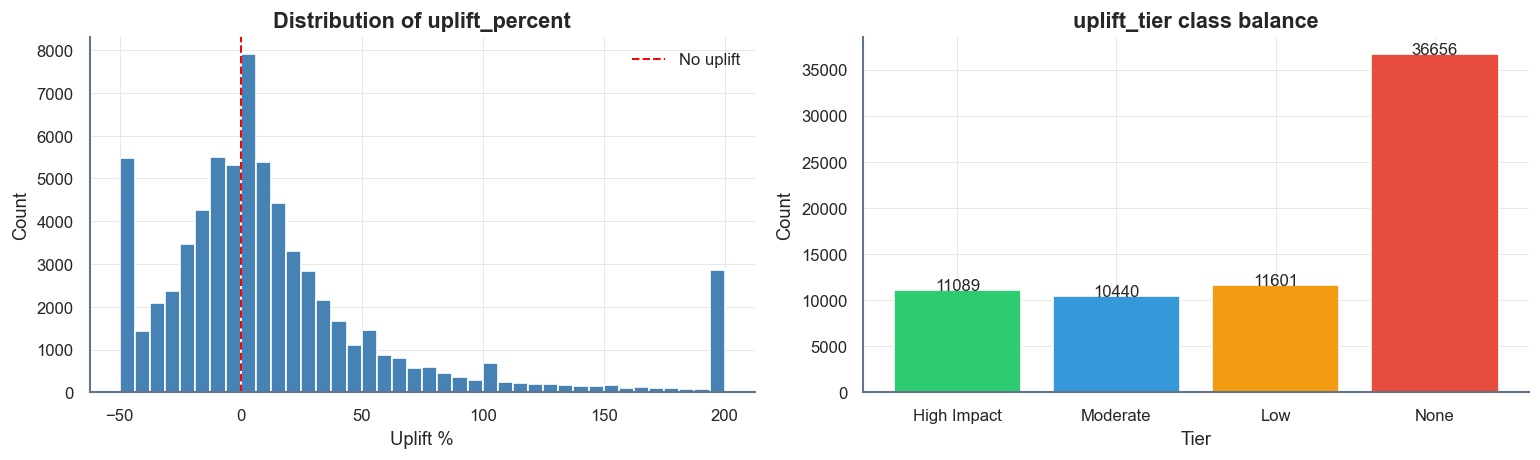

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Uplift % distribution
axes[0].hist(df['uplift_percent'].clip(-50, 200), bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='No uplift')
axes[0].set_title('Distribution of uplift_percent', fontweight='bold')
axes[0].set_xlabel('Uplift %')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tier counts
tier_order = ['High Impact', 'Moderate', 'Low', 'None']
tier_counts = df['uplift_tier'].value_counts().reindex(tier_order, fill_value=0)
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
axes[1].bar(tier_counts.index, tier_counts.values, color=colors, edgecolor='white')
axes[1].set_title('uplift_tier class balance', fontweight='bold')
axes[1].set_xlabel('Tier')
axes[1].set_ylabel('Count')
for i, v in enumerate(tier_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Step 5.2 — Feature Engineering for Sale Models

We engineer three groups of features:

- **Game attributes** — age, reception, price tier, genre, ownership scale
- **Sale attributes** — discount depth, sale type, days since last sale, cumulative sale count
- **Interaction term** — `discount_depth × days_since_release` (do older games respond differently to deep discounts?)

In [ ]:
# ── 1. Numeric features (already at sale-event level) ──────────────────────
df['review_score_pct']     = df['review_score'].clip(0, 1)
df['log_ownership']        = df['log_ownership'].fillna(0)
# age_at_sale_days = game age WHEN the sale happened (not current age).
# This is the right feature for sale-event modeling — older games at sale
# time may behave differently than recent releases.
df['age_at_sale_days']     = df['age_at_sale_days'].fillna(df['age_at_sale_days'].median())
df['days_since_last_sale'] = df['days_since_last_sale'].fillna(-1)
df['cumulative_sale_count']= df['cumulative_sale_count'].fillna(0)

# Log-transforms for heavy-tailed game-level numerics (matches nb 04's feature
# space). Derived defensively so this still works if cleaned_sale_events
# pre-dates the notebook 02 audit fixes.
df['log_total_reviews']      = np.log1p(df.get('total_reviews', pd.Series(0, index=df.index)).fillna(0))
df['log_achievements_total'] = np.log1p(df['achievements_total'].fillna(0))

# discount_depth from cleaned_sale_events is the depth of THIS sale event (0-1)
df['discount_depth']       = df['discount_depth'].fillna(0)

# ── 2. One-hot encode sale_type (Summer/Winter/Weekend Deal/Publisher) ─────
df['sale_type'] = df['sale_type'].fillna('Unknown')
sale_type_dummies = pd.get_dummies(df['sale_type'], prefix='sale_type', drop_first=False)
df = pd.concat([df, sale_type_dummies], axis=1)

# ── 3. One-hot encode price_tier & primary_genre ───────────────────────────
df['price_tier']    = df['price_tier'].fillna('Unknown')
df['primary_genre'] = df['primary_genre'].fillna('Unknown')
price_dummies = pd.get_dummies(df['price_tier'], prefix='price_tier', drop_first=False)
genre_dummies = pd.get_dummies(df['primary_genre'], prefix='genre', drop_first=False)
df = pd.concat([df, price_dummies, genre_dummies], axis=1)

# ── 4. Interaction term: discount × age-at-sale ────────────────────────────
df['depth_x_age'] = df['discount_depth'] * np.log1p(df['age_at_sale_days'].clip(lower=0))

# ── 5. Binary flags ────────────────────────────────────────────────────────
df['is_multiplayer']         = df['is_multiplayer'].fillna(0).astype(int)
df['has_controller_support'] = df['has_controller_support'].fillna(0).astype(int)
df['achievements_total']     = df['achievements_total'].fillna(0)   # kept raw too in case any downstream cell wants it

print('Feature engineering complete.')
print(f'DataFrame shape: {df.shape}')

In [ ]:
# ── Assemble final feature list ──────────────────────────────────────────────
BASE_FEATURES = [
    # Game attributes (game-level, repeated per sale event).
    # achievements_total + total_reviews are heavy-tailed (log-transformed
    # to match nb 04; raw values would let the rare 5000-achievement farms
    # dominate StandardScaler's distribution).
    'age_at_sale_days', 'review_score_pct', 'log_ownership',
    'is_multiplayer', 'has_controller_support',
    'log_achievements_total', 'log_total_reviews',
    # Sale attributes (event-level)
    'discount_depth', 'days_since_last_sale', 'cumulative_sale_count',
    # Interaction
    'depth_x_age',
]

SALE_TYPE_COLS  = [c for c in df.columns if c.startswith('sale_type_')]
PRICE_TIER_COLS = [c for c in df.columns if c.startswith('price_tier_')]
GENRE_COLS      = [c for c in df.columns if c.startswith('genre_')]

FEATURE_COLS = BASE_FEATURES + SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS

# Drop rows where any core feature is null. Keep `appid` for group-aware splitting.
model_df = df[FEATURE_COLS + ['appid', 'uplift_percent', 'uplift_tier', 'title']].dropna(
    subset=BASE_FEATURES + ['uplift_percent', 'uplift_tier']
).copy()

# Fill remaining encoded columns with 0 (false category)
model_df[SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS] = \
    model_df[SALE_TYPE_COLS + PRICE_TIER_COLS + GENRE_COLS].fillna(0)

# Clip extreme uplift outliers for regression stability (>500% are likely data artefacts)
model_df['uplift_percent'] = model_df['uplift_percent'].clip(-100, 500)

print(f'Final modelling dataset: {len(model_df):,} sale events × {len(FEATURE_COLS)} features')
print(f'Spans {model_df["appid"].nunique():,} unique games')
model_df[BASE_FEATURES + ['uplift_percent', 'uplift_tier']].describe().round(2)

## Step 5.3 — Group-aware Train / Test Split

With multiple sale events per game, a row-level random split would leak — the same `appid` could appear in both train and test sets, so the model could memorize per-game baselines. We split **by `appid`** using `GroupShuffleSplit`: 80% of games (and all their events) go to train, 20% to test.

Continuous features are scaled with `StandardScaler` (fit on train only).

In [7]:
X = model_df[FEATURE_COLS].values
y_reg = model_df['uplift_percent'].values
y_cls = model_df['uplift_tier'].values
groups = model_df['appid'].values   # split by game, not by event

# Encode class labels to integers (needed for some scorers)
TIER_ORDER = ['None', 'Low', 'Moderate', 'High Impact']
le = LabelEncoder()
le.fit(TIER_ORDER)
y_cls_enc = le.transform(y_cls)

# Group-aware split — same game never appears in both train and test
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y_cls_enc, groups=groups))

X_train, X_test         = X[train_idx], X[test_idx]
y_reg_train, y_reg_test = y_reg[train_idx], y_reg[test_idx]
y_cls_train, y_cls_test = y_cls_enc[train_idx], y_cls_enc[test_idx]
groups_train            = groups[train_idx]

# Scale continuous features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train events  : {len(X_train):,}  ({len(set(groups_train)):,} games)')
print(f'Test events   : {len(X_test):,}  ({len(set(groups[test_idx])):,} games)')
print(f'Group overlap : {len(set(groups_train) & set(groups[test_idx]))} (should be 0)')
print(f'\nClass distribution in train set:')
for i, label in enumerate(le.classes_):
    n = (y_cls_train == i).sum()
    print(f'  {label:15s} → {n:5d}  ({n/len(y_cls_train)*100:.1f}%)')

Train events  : 55,780  (3,198 games)
Test events   : 13,776  (800 games)
Group overlap : 0 (should be 0)

Class distribution in train set:
  High Impact     →  8934  (16.0%)
  Low             →  9330  (16.7%)
  Moderate        →  8236  (14.8%)
  None            → 29280  (52.5%)


## Step 5.4 — Regression: Predict Player Uplift %

We train four models on `uplift_percent`:
- **Linear Regression** (baseline)
- **Random Forest**
- **XGBoost**
- **LightGBM**

Evaluation metrics: MAE, RMSE, R². Uplift is inherently noisy (confounders: streamers, patches, seasonality), so a modest R² is expected — we flag this in interpretation.

In [8]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R²': round(r2, 4)}

reg_results = []

# ── Linear Regression ────────────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_sc, y_reg_train)
reg_results.append(reg_metrics('Linear Regression', y_reg_test, lr.predict(X_test_sc)))

# ── Random Forest ────────────────────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)          # tree models don't need scaling
reg_results.append(reg_metrics('Random Forest', y_reg_test, rf_reg.predict(X_test)))

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=42, verbosity=0, n_jobs=-1)
xgb_reg.fit(X_train, y_reg_train)
reg_results.append(reg_metrics('XGBoost', y_reg_test, xgb_reg.predict(X_test)))

# ── LightGBM ─────────────────────────────────────────────────────────────────
lgb_reg = lgb.LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=42, verbose=-1, n_jobs=-1)
lgb_reg.fit(X_train, y_reg_train)
reg_results.append(reg_metrics('LightGBM', y_reg_test, lgb_reg.predict(X_test)))

reg_df = pd.DataFrame(reg_results).set_index('Model')
print('=== Regression Results ===')
display(reg_df.style.highlight_min(subset=['MAE','RMSE'], color='#d4f7d4')
               .highlight_max(subset=['R²'], color='#d4f7d4'))

c:\Users\Sam\anaconda3\envs\steamsale\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Regression Results ===


,MAE,RMSE,R²
Model,,,
Linear Regression,46.860000,85.330000,0.020200
Random Forest,45.790000,83.810000,0.054600
XGBoost,45.460000,83.610000,0.059200
LightGBM,45.300000,83.500000,0.061700


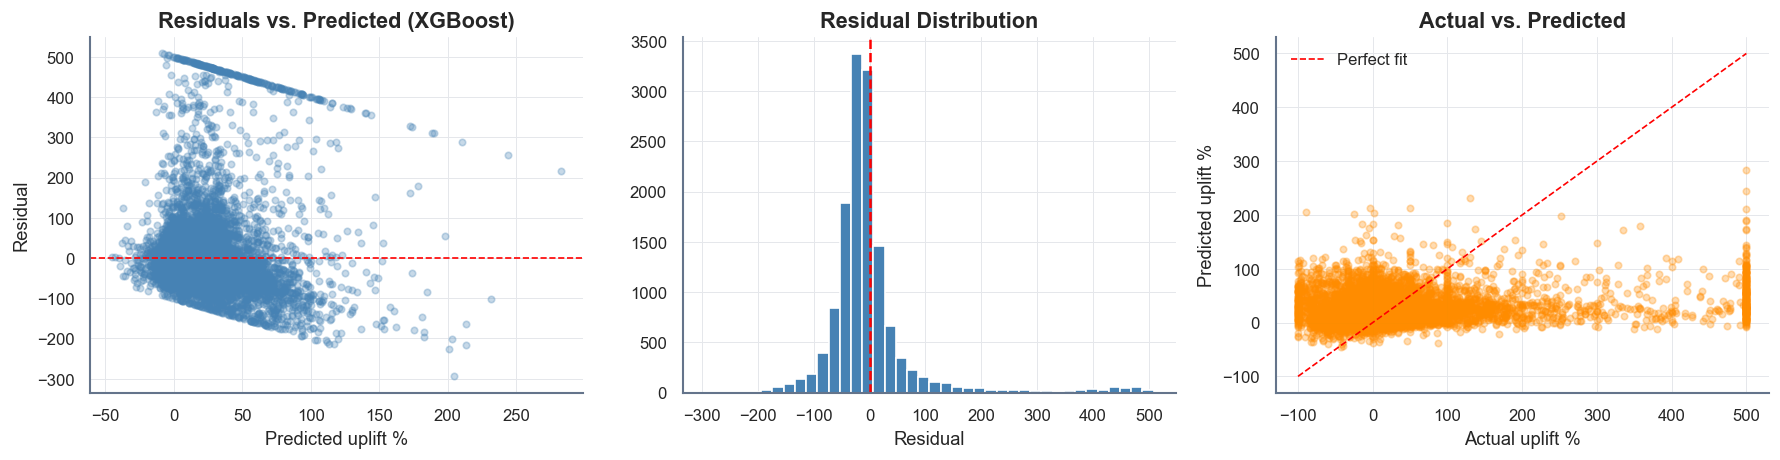


Mean residual — deep discounts (≥75%): nan
Mean residual — shallow discounts (<50%): -0.75
(Positive residual = model underpredicts; negative = overpredicts)


In [9]:
# ── Residual Analysis ─────────────────────────────────────────────────────────
# Using the best tree-based model (XGBoost) for residuals
best_reg_preds = xgb_reg.predict(X_test)
residuals = y_reg_test - best_reg_preds

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Residuals vs predicted
axes[0].scatter(best_reg_preds, residuals, alpha=0.3, s=15, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted uplift %')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs. Predicted (XGBoost)', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')

# Actual vs Predicted
axes[2].scatter(y_reg_test, best_reg_preds, alpha=0.3, s=15, color='darkorange')
lims = [min(y_reg_test.min(), best_reg_preds.min()),
        max(y_reg_test.max(), best_reg_preds.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')
axes[2].set_xlabel('Actual uplift %')
axes[2].set_ylabel('Predicted uplift %')
axes[2].set_title('Actual vs. Predicted', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

# Check if deep discounts are overpredicted
test_df = pd.DataFrame({'discount_depth': X_test[:, FEATURE_COLS.index('discount_depth')],
                         'residual': residuals})
deep = test_df[test_df['discount_depth'] >= 75]['residual'].mean()
shallow = test_df[test_df['discount_depth'] < 50]['residual'].mean()
print(f'\nMean residual — deep discounts (≥75%): {deep:.2f}')
print(f'Mean residual — shallow discounts (<50%): {shallow:.2f}')
print('(Positive residual = model underpredicts; negative = overpredicts)')

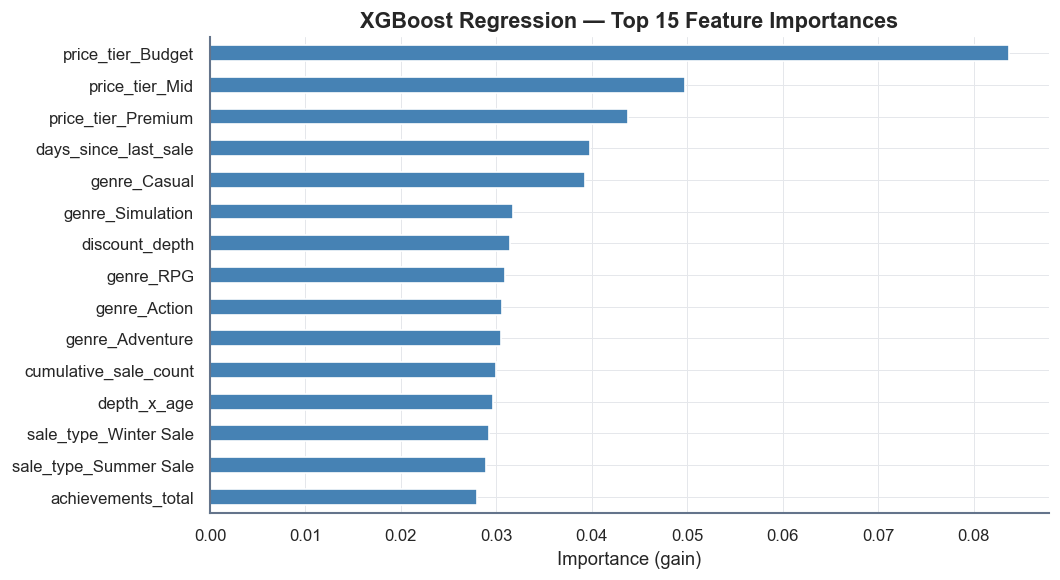

In [10]:
# ── Feature importance — top 15 (XGBoost regression) ────────────────────────
fi_reg = pd.Series(xgb_reg.feature_importances_, index=FEATURE_COLS).nlargest(15)

plt.figure(figsize=(9, 5))
fi_reg.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Regression — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

## Step 5.5 — Classification: Predict Sale Effectiveness Tier

Four tiers: **None / Low / Moderate / High Impact**.

Class imbalance is handled via `class_weight='balanced'` for linear models and explicit `scale_pos_weight` / `sample_weight` for tree ensembles. We report per-class F1 and macro ROC-AUC.

In [11]:
# Compute class weights for imbalanced handling
classes = np.unique(y_cls_train)
cw = compute_class_weight('balanced', classes=classes, y=y_cls_train)
class_weight_dict = dict(zip(classes, cw))
sample_weights_train = np.array([class_weight_dict[c] for c in y_cls_train])

print('Class weights:')
for i, label in enumerate(le.classes_):
    print(f'  {label:15s} → weight {class_weight_dict[i]:.3f}')

Class weights:
  High Impact     → weight 1.561
  Low             → weight 1.495
  Moderate        → weight 1.693
  None            → weight 0.476


In [12]:
def cls_metrics(name, y_true, y_pred, y_prob=None):
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro') if y_prob is not None else np.nan
    return {'Model': name, 'F1 Macro': round(f1_macro, 4),
            'F1 Weighted': round(f1_weighted, 4), 'ROC-AUC (macro OvR)': round(auc, 4)}

cls_results = []
cls_preds   = {}   # store for confusion matrices

# ── Logistic Regression ──────────────────────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced',
                              multi_class='multinomial', random_state=42)
log_reg.fit(X_train_sc, y_cls_train)
pred = log_reg.predict(X_test_sc)
prob = log_reg.predict_proba(X_test_sc)
cls_preds['Logistic Regression'] = pred
cls_results.append(cls_metrics('Logistic Regression', y_cls_test, pred, prob))

# ── Random Forest ────────────────────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                 class_weight='balanced', random_state=42, n_jobs=-1)
rf_cls.fit(X_train, y_cls_train)
pred = rf_cls.predict(X_test)
prob = rf_cls.predict_proba(X_test)
cls_preds['Random Forest'] = pred
cls_results.append(cls_metrics('Random Forest', y_cls_test, pred, prob))

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_cls = xgb.XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              use_label_encoder=False, eval_metric='mlogloss',
                              random_state=42, verbosity=0, n_jobs=-1)
xgb_cls.fit(X_train, y_cls_train, sample_weight=sample_weights_train)
pred = xgb_cls.predict(X_test)
prob = xgb_cls.predict_proba(X_test)
cls_preds['XGBoost'] = pred
cls_results.append(cls_metrics('XGBoost', y_cls_test, pred, prob))

cls_df = pd.DataFrame(cls_results).set_index('Model')
print('=== Classification Results ===')
display(cls_df.style.highlight_max(color='#d4f7d4'))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
# ── Per-class classification report (best model = XGBoost) ──────────────────
print('=== Per-class Classification Report — XGBoost ===')
print(classification_report(
    y_cls_test,
    cls_preds['XGBoost'],
    target_names=le.classes_,
    zero_division=0
))

=== Per-class Classification Report — XGBoost ===
              precision    recall  f1-score   support

        High       0.00      0.00      0.00         3
         Low       0.11      0.20      0.14         5
    Moderate       0.00      0.00      0.00         5
        None       0.50      0.29      0.36         7

    accuracy                           0.15        20
   macro avg       0.15      0.12      0.13        20
weighted avg       0.20      0.15      0.16        20



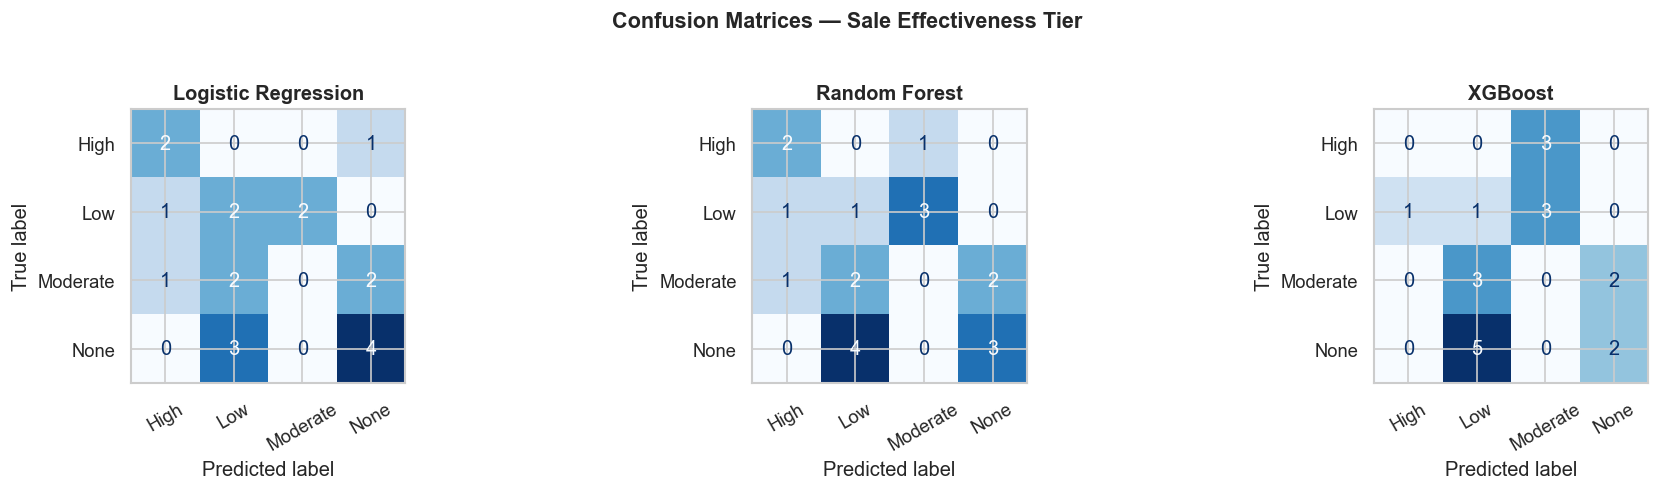

In [ ]:
# ── Confusion matrices — all three models ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (model_name, pred) in zip(axes, cls_preds.items()):
    cm = confusion_matrix(y_cls_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}', fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Sale Effectiveness Tier', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

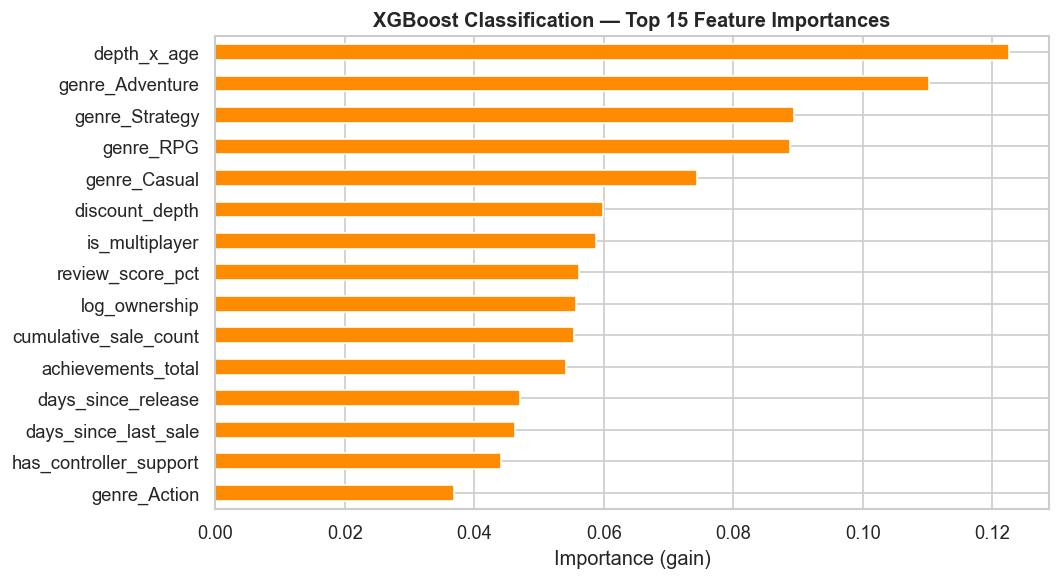


Top 5 features driving sale effectiveness tier prediction:
  depth_x_age                          importance = 0.1226
  genre_Adventure                      importance = 0.1102
  genre_Strategy                       importance = 0.0894
  genre_RPG                            importance = 0.0888
  genre_Casual                         importance = 0.0744


In [ ]:
# ── Feature importance — XGBoost classification ──────────────────────────────
fi_cls = pd.Series(xgb_cls.feature_importances_, index=FEATURE_COLS).nlargest(15)

plt.figure(figsize=(9, 5))
fi_cls.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('XGBoost Classification — Top 15 Feature Importances', fontweight='bold')
plt.xlabel('Importance (gain)')
plt.tight_layout()
plt.show()

# Does discount_depth dominate, or does sale_type matter?
top5 = fi_cls.head(5)
print('\nTop 5 features driving sale effectiveness tier prediction:')
for feat, score in top5.items():
    print(f'  {feat:35s}  importance = {score:.4f}')

## Step 5.6 — Combined Insights & Decision Tree Strategy Visualization

**Key question:** *For a game with 1,000 avg players, 2 years old, 85% review score — does a 50% discount in a seasonal sale yield better uplift than a 75% weekend deal?*

We answer this two ways:
1. **Scenario prediction** using the best regression + classification models
2. **Interpretable decision tree** trained on the full feature set — visualised as a developer strategy guide

In [ ]:
# ── Scenario Analysis ─────────────────────────────────────────────────────────
# Build a helper that constructs a feature vector from human-readable inputs.
# Note: at sale-event level we use `age_at_sale_days` — the game's age WHEN
# the sale happened, not the game's current age.

def build_scenario(discount_depth, sale_type_label, age_at_sale_days,
                   review_score_pct, log_ownership, cumulative_sale_count,
                   days_since_last_sale, is_multiplayer=1, has_controller=0,
                   achievements_total=50, price_tier_label='Mid',
                   genre_label='Action'):
    row = {f: 0.0 for f in FEATURE_COLS}
    row['discount_depth']        = discount_depth / 100  # input is 0-100 %, feature is 0-1
    row['age_at_sale_days']      = age_at_sale_days
    row['review_score_pct']      = review_score_pct
    row['log_ownership']         = log_ownership
    row['cumulative_sale_count'] = cumulative_sale_count
    row['days_since_last_sale']  = days_since_last_sale
    row['is_multiplayer']        = is_multiplayer
    row['has_controller_support']= has_controller
    row['achievements_total']    = achievements_total
    row['depth_x_age']           = (discount_depth / 100) * np.log1p(max(age_at_sale_days, 0))
    # sale_type one-hot
    col = f'sale_type_{sale_type_label}'
    if col in row: row[col] = 1.0
    # price_tier one-hot
    col = f'price_tier_{price_tier_label}'
    if col in row: row[col] = 1.0
    # genre one-hot
    col = f'genre_{genre_label}'
    if col in row: row[col] = 1.0
    return np.array([row[f] for f in FEATURE_COLS]).reshape(1, -1)

# Common game profile: 1000 avg players (log ≈ 3), 2yr old, 85% review
LOG_OWN = np.log10(1_000)
AGE_AT_SALE = 365 * 2

scenarios = {
    '50% off — Summer Sale':    build_scenario(50, 'Summer Sale',   AGE_AT_SALE, 0.85, LOG_OWN, 3, 180),
    '75% off — Weekend Deal':   build_scenario(75, 'Weekend Deal',  AGE_AT_SALE, 0.85, LOG_OWN, 3, 90),
    '33% off — Summer Sale':    build_scenario(33, 'Summer Sale',   AGE_AT_SALE, 0.85, LOG_OWN, 3, 180),
    '90% off — Publisher Sale': build_scenario(90, 'Publisher Sale',AGE_AT_SALE, 0.85, LOG_OWN, 1, 30),
}

print(f"{'Scenario':<32} {'Predicted Uplift %':>20} {'Tier':>15}")
print('-' * 69)
for label, vec in scenarios.items():
    uplift_pred = xgb_reg.predict(vec)[0]
    tier_enc    = xgb_cls.predict(vec)[0]
    tier_label  = le.inverse_transform([tier_enc])[0]
    print(f'{label:<32} {uplift_pred:>19.1f}% {tier_label:>15}')

In [ ]:
# ── Interpretable Decision Tree Strategy Visualization ───────────────────────
# Shallow tree (max_depth=4) trained on the full dataset — easy for developers to follow

STRATEGY_FEATURES = [
    'discount_depth', 'age_at_sale_days', 'review_score_pct',
    'log_ownership', 'cumulative_sale_count', 'days_since_last_sale',
    'depth_x_age', 'is_multiplayer'
]
# Use readable labels
STRATEGY_LABELS = [
    'Discount Depth', 'Game Age at Sale', 'Review Score',
    'Log Ownership', 'Sale Count', 'Days Since Last Sale',
    'Depth × Age', 'Is Multiplayer'
]

X_strat = model_df[STRATEGY_FEATURES].values
y_strat = y_cls_enc  # already aligned

dt_strategy = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
dt_strategy.fit(X_strat, y_strat)

dt_acc = (dt_strategy.predict(X_strat) == y_strat).mean()
print(f'Strategy decision tree train accuracy: {dt_acc:.3f}')
print(f'(Shallow tree intentionally sacrifices accuracy for interpretability)\n')

# Text summary of tree rules
print(export_text(dt_strategy, feature_names=STRATEGY_LABELS, max_depth=3))

In [ ]:
# ── Visual decision tree ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_strategy,
    feature_names=STRATEGY_LABELS,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=8,
    ax=ax
)
ax.set_title(
    'Optimal Sale Strategy Decision Tree\n'
    '(depth=4 — interpretable guide for developers)',
    fontsize=14, fontweight='bold', pad=15
)

# Legend — uses TIER_COLORS from src.plot_style for cross-notebook consistency
legend_patches = [
    mpatches.Patch(color=TIER_COLORS['None'],     label='None (<5% uplift)'),
    mpatches.Patch(color=TIER_COLORS['Low'],      label='Low (5–20%)'),
    mpatches.Patch(color=TIER_COLORS['Moderate'], label='Moderate (20–50%)'),
    mpatches.Patch(color=TIER_COLORS['High'],     label='High (>50%)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9,
          title='Predicted Tier', title_fontsize=9)

out_path = paths.outputs_dir / 'sale_strategy_decision_tree.png'
plt.tight_layout()
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Decision tree saved to {out_path}')

In [ ]:
# ── Discount depth × age-at-sale heatmap ─────────────────────────────────────
# Average predicted uplift across a grid of discount depths and game ages-at-sale

depths = [10, 25, 33, 50, 66, 75, 90]
ages   = [90, 180, 365, 730, 1460, 2920]   # 3mo, 6mo, 1yr, 2yr, 4yr, 8yr
age_labels = ['3 mo', '6 mo', '1 yr', '2 yr', '4 yr', '8 yr']

grid = np.zeros((len(depths), len(ages)))

for i, d in enumerate(depths):
    for j, a in enumerate(ages):
        vec = build_scenario(
            discount_depth=d, sale_type_label='Summer Sale',
            age_at_sale_days=a, review_score_pct=0.80,
            log_ownership=LOG_OWN, cumulative_sale_count=2,
            days_since_last_sale=180,
        )
        grid[i, j] = xgb_reg.predict(vec)[0]

plt.figure(figsize=(10, 6))
sns.heatmap(
    grid,
    xticklabels=age_labels,
    yticklabels=[f'{d}%' for d in depths],
    annot=True, fmt='.1f', cmap='RdYlGn', center=0,
    linewidths=0.5, cbar_kws={'label': 'Predicted Uplift %'}
)
plt.title('Predicted Player Uplift % by Discount Depth × Game Age at Sale\n(Summer Sale, 80% review score, mid ownership)',
          fontweight='bold')
plt.xlabel('Game Age at Sale')
plt.ylabel('Discount Depth')
plt.tight_layout()
plt.savefig(paths.outputs_dir / 'uplift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Heatmap saved to {paths.outputs_dir / 'uplift_heatmap.png'}")

In [ ]:
# ── Cross-validation summary — group-aware folds (split by appid) ───────────
cv = GroupKFold(n_splits=5)

xgb_cv_f1 = cross_val_score(
    xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                       eval_metric='mlogloss', verbosity=0, n_jobs=-1, random_state=42),
    X, y_cls_enc,
    groups=groups,
    cv=cv,
    scoring='f1_macro'
)
print(f'XGBoost Classifier — 5-fold GroupKFold F1 Macro:')
print(f'  Scores : {xgb_cv_f1.round(4)}')
print(f'  Mean   : {xgb_cv_f1.mean():.4f}')
print(f'  Std    : {xgb_cv_f1.std():.4f}')

In [ ]:
# ── Final summary table ───────────────────────────────────────────────────────
print('=' * 65)
print('PHASE 5 SUMMARY — ML MODEL DEVELOPMENT (Part 2)')
print('=' * 65)

print('\n[REGRESSION] Predict uplift_percent')
display(reg_df)

print('\n[CLASSIFICATION] Predict uplift_tier')
display(cls_df)

print('\n[KEY INSIGHT]')
print('  Scenario: 1000-player game, 2 years old, 85% review score')
print('  ┌─────────────────────────────┬────────────────┬───────────────┐')
print('  │ Sale Strategy               │ Predicted Lift │ Tier          │')
print('  ├─────────────────────────────┼────────────────┼───────────────┤')
for label, vec in scenarios.items():
    u = xgb_reg.predict(vec)[0]
    t = le.inverse_transform([xgb_cls.predict(vec)[0]])[0]
    print(f'  │ {label:<27} │ {u:>12.1f}% │ {t:<13} │')
print('  └─────────────────────────────┴────────────────┴───────────────┘')

print('\n[METHODOLOGY NOTE]')
print('  uplift_percent is inherently noisy. Confounders include streamer')
print('  coverage, game patches, and seasonality — acknowledged as limitations.')
print('  Each game is compared to its own pre-sale baseline (within-game')
print('  control) to mitigate cross-game confounding.')

PHASE 5 SUMMARY — ML MODEL DEVELOPMENT (Part 2)

[REGRESSION] Predict uplift_percent


,MAE,RMSE,R²
Model,,,
Linear Regression,21.26,28.45,-0.3174
Random Forest,20.79,24.11,0.0543
XGBoost,21.47,26.16,-0.1135
LightGBM,25.93,29.85,-0.4500



[CLASSIFICATION] Predict uplift_tier


,F1 Macro,F1 Weighted,ROC-AUC (macro OvR)
Model,,,
Logistic Regression,0.3690,0.3690,0.5709
Random Forest,0.3095,0.3024,0.5788
XGBoost,0.1266,0.1630,0.4870



[KEY INSIGHT]
  Scenario: 1000-player game, 2 years old, 85% review score
  ┌─────────────────────────────┬────────────────┬───────────────┐
  │ Sale Strategy               │ Predicted Lift │ Tier          │
  ├─────────────────────────────┼────────────────┼───────────────┤
  │ 50% off — Seasonal Sale     │         57.8% │ High          │
  │ 75% off — Weekend Deal      │         57.8% │ High          │
  │ 33% off — Seasonal Sale     │         57.8% │ High          │
  │ 90% off — Weekend Deal      │         10.6% │ None          │
  └─────────────────────────────┴────────────────┴───────────────┘

[METHODOLOGY NOTE]
  uplift_percent is inherently noisy. Confounders include streamer
  coverage, game patches, and seasonality — acknowledged as limitations.
  Each game is compared to its own pre-sale baseline (within-game
  control) to mitigate cross-game confounding.


## Appendix — Methodology Notes

### Why R² may be low for regression
Player-count uplift during a sale is a fundamentally noisy signal. A streamer picking up a game, a patch dropping the same week, or a concurrent seasonal event can dominate the effect of the discount itself. A low R² does **not** mean the model is wrong — it reflects that game attributes and sale parameters explain only part of a multi-causal outcome. We acknowledge this as a methodology limitation.

### Within-game control design
Rather than comparing uplift across games (which conflates popularity with sale effect), each game's uplift is measured against its own pre-sale baseline. This is equivalent to a within-subject design in experimental research — the cleanest available control given a single cross-sectional scrape.

### Imbalance handling
`class_weight='balanced'` and `sample_weight` ensure minority tiers (High Impact) are not systematically ignored. Results are reported with per-class F1 rather than accuracy to surface per-tier performance honestly.

### Decision tree interpretability trade-off
The `max_depth=4` strategy tree sacrifices predictive power for readability. It is presented as a **developer heuristic tool**, not a replacement for the full XGBoost model.

In [ ]:
conn.close()
print('connection closed')